# HW14: Эмбеддинги, FAISS и Mini-RAG

**Тема работы:** Построение полноценного retrieval-конвейера и mini-RAG на основе векторного поиска.

**База знаний:** История технологий и изобретений (12 документов)

## 1. Импорты, seed и среда

In [1]:
# Базовые библиотеки
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

# Определение устройства для PyTorch (если используется)
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

# Проверка доступности FAISS
try:
    import faiss
    FAISS_AVAILABLE = True
    print("FAISS доступен")
except ImportError:
    FAISS_AVAILABLE = False
    print("FAISS не доступен, будет использован fallback")

# Проверка доступности sentence-transformers
try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
    print("sentence-transformers доступен")
except ImportError:
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    print("sentence-transformers не доступен")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Устройство для работы: cpu
FAISS доступен
sentence-transformers доступен
NumPy: 2.3.5
Pandas: 2.3.3


## 2. База знаний и первичный анализ

**Выбранная база знаний:** История технологий и изобретений.

**Почему эта тема:**
- Документы содержат конкретные факты (даты, имена, технологии)
- Позволяет задавать разнообразные фактологические вопросы
- Темы пересекаются, что создаёт интересные кейсы для retrieval
- 12 документов, после чанкинга даёт ~30-50 фрагментов

In [4]:
# База знаний: История технологий и изобретений
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Изобретение транзистора",
        "text": (
            "Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. "
            "Это изобретение заменило громоздкие вакуумные лампы и позволило создавать миниатюрные электронные устройства. "
            "Транзисторы стали основой для компьютеров, мобильных телефонов и всей современной электроники. "
            "За это открытие ученые получили Нобелевскую премию по физике в 1956 году."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Создание интернета",
        "text": (
            "Интернет берет начало в сети ARPANET, созданной в 1969 году Министерством обороны США. "
            "Первоначально сеть соединяла всего 4 университетских компьютера. "
            "В 1983 году был внедрен протокол TCP/IP, который стал стандартом для передачи данных. "
            "В 1991 году Тим Бернерс-Ли изобрел World Wide Web, предложив HTTP, HTML и первые веб-браузеры, "
            "что сделало интернет доступным для широкой публики."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Персональные компьютеры",
        "text": (
            "Первым массовым персональным компьютером стал Altair 8800 в 1975 году. "
            "В 1976 году Стив Джобс и Стив Возняк основали Apple и выпустили Apple I. "
            "В 1981 году IBM представила свой первый персональный компьютер с открытой архитектурой, "
            "что позволило другим производителям создавать совместимые устройства. "
            "Microsoft разработала MS-DOS, а затем Windows, сделав компьютеры доступными для миллионов пользователей."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "История искусственного интеллекта",
        "text": (
            "Термин 'искусственный интеллект' был предложен в 1956 году на Дартмутской конференции. "
            "В 1997 году компьютер IBM Deep Blue победил чемпиона мира по шахматам Гарри Каспарова. "
            "В 2012 году нейронные сети показали прорыв в распознавании изображений. "
            "В 2016 году программа AlphaGo от Google DeepMind победила чемпиона мира по игре Го, "
            "что считалось недостижимым для ИИ еще за несколько лет до этого."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Развитие мобильной связи",
        "text": (
            "Первый коммерческий сотовый телефон Motorola DynaTAC 8000X появился в 1983 году. "
            "Он весил почти 1 кг и стоил около 4000 долларов. "
            "В 1992 году было отправлено первое SMS-сообщение. "
            "В 2007 году Apple представила iPhone, который совершил революцию в мобильной индустрии, "
            "предложив сенсорный экран и полноценную мобильную операционную систему."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Изобретение микропроцессора",
        "text": (
            "Первый микропроцессор Intel 4004 был создан в 1971 году. "
            "Он содержал 2300 транзисторов и работал на частоте 740 кГц. "
            "Микропроцессоры позволили создавать программируемые калькуляторы, "
            "а затем и персональные компьютеры. "
            "Сегодня современные процессоры содержат миллиарды транзисторов и "
            "используют передовые технологии с нормами 3-5 нанометров."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Технология Bluetooth",
        "text": (
            "Bluetooth был разработан в 1994 году компанией Ericsson как беспроводная альтернатива кабелям. "
            "Название происходит от датского короля Харальда Синезубого (Bluetooth), объединившего племена. "
            "Стандарт Bluetooth 1.0 появился в 1999 году. "
            "Сегодня Bluetooth используется в наушниках, колонках, клавиатурах и для передачи файлов. "
            "Bluetooth Low Energy (BLE) позволяет создавать устройства с очень низким энергопотреблением."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "История видеоигр",
        "text": (
            "Первой коммерческой видеоигрой стала Computer Space в 1971 году. "
            "В 1972 году Atari выпустила Pong — простейший симулятор настольного тенниса. "
            "В 1980-х Nintendo спасла индустрию после кризиса, выпустив NES и игру Super Mario Bros. "
            "В 1990-х появились 3D-игры и такие консоли, как PlayStation и Nintendo 64. "
            "Сегодня индустрия видеоигр приносит больше дохода, чем кино и музыка вместе взятые."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Создание WWW и веб-технологий",
        "text": (
            "Тим Бернерс-Ли в 1989 году предложил концепцию Всемирной паутины, работая в CERN. "
            "Он создал первый веб-сервер, первый веб-браузер и язык HTML. "
            "В 1993 году CERN объявил, что WWW будет бесплатной для всех. "
            "Появились первые поисковые системы: WebCrawler, Yahoo, а затем Google. "
            "Сегодня веб-технологии включают HTML5, CSS3, JavaScript и множество фреймворков."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Искусственный интеллект в повседневной жизни",
        "text": (
            "ИИ уже используется в распознавании лиц на смартфонах и в системах безопасности. "
            "Рекомендательные системы YouTube, Netflix и Spotify анализируют наши предпочтения. "
            "Голосовые помощники Siri, Alexa и Google Assistant понимают естественную речь. "
            "В медицине ИИ помогает диагностировать заболевания по снимкам МРТ и рентгена. "
            "Автопилоты Tesla используют глубокое обучение для распознавания объектов на дороге."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Эволюция операционных систем",
        "text": (
            "В 1969 году в Bell Labs создали UNIX — многопользовательскую ОС. "
            "В 1985 году Microsoft выпустила Windows 1.0, графическую оболочку для MS-DOS. "
            "В 1991 году Линус Торвальдс создал Linux, свободную UNIX-подобную ОС. "
            "Apple в 2001 году представила Mac OS X на основе NeXTSTEP. "
            "Сегодня доминируют Windows, macOS, Linux и мобильные ОС — Android и iOS."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Будущее технологий и тренды",
        "text": (
            "Квантовые компьютеры обещают решать задачи, недоступные классическим компьютерам. "
            "Искусственный интеллект продолжает развиваться, появляются генеративные модели, "
            "способные создавать текст, изображения и видео. "
            "Интернет вещей (IoT) соединяет миллиарды устройств. "
            "Нейроинтерфейсы, такие как разработки Neuralink, могут изменить взаимодействие "
            "человека с компьютером. "
            "Блокчейн и криптовалюты предлагают новые модели децентрализованных систем."
        ),
    },
]

docs_df = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df))
display(docs_df[["doc_id", "title"]].head(5))

print("\nПример документа (doc_01):")
print(documents[0]["text"][:200] + "...")

Размер корпуса: 12


,doc_id,title
0,doc_01,Изобретение транзистора
1,doc_02,Создание интернета
2,doc_03,Персональные компьютеры
3,doc_04,История искусственного интеллекта
4,doc_05,Развитие мобильной связи



Пример документа (doc_01):
Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. Это изобретение заменило громоздкие вакуумные лампы и позволило создавать миниат...


## 3. Чанкинг документов

**Выбранные параметры:**
- `chunk_size = 28` слов (баланс между контекстом и точностью)
- `overlap = 8` слов (чтобы важная мысль не разрывалась на границе)

**Почему такие параметры:**
- 28 слов достаточно для передачи законченной мысли
- Overlap 8 слов (около 30%) обеспечивает плавный переход между чанками
- При таком размере получается оптимальное количество чанков для учебного корпуса

In [5]:
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


# Показываем пример чанкинга на одном документе
sample_doc = documents[0]
sample_chunks = chunk_text(sample_doc["text"], chunk_size=28, overlap=8)

print(f"Документ: {sample_doc['title']}")
print(f"Исходный текст: {sample_doc['text'][:150]}...")
print(f"\nКоличество чанков: {len(sample_chunks)}")
print("\nПримеры чанков:")
for i, chunk in enumerate(sample_chunks[:2]):
    print(f"\nЧанк {i+1}:")
    print(f"  {chunk[:150]}...")
    print(f"  Длина: {len(chunk.split())} слов")

# Построение всех чанков
def build_chunks(documents: List[Dict[str, str]], chunk_size: int = 28, overlap: int = 8) -> List[Dict]:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx:02d}",
                "chunk_text": chunk_text_value,
            })
    return pd.DataFrame(rows)


chunks_df = build_chunks(documents, chunk_size=28, overlap=8)
print(f"\nВсего чанков: {len(chunks_df)}")
display(chunks_df.head())

Документ: Изобретение транзистора
Исходный текст: Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. Это изобретение заменило громо...

Количество чанков: 3

Примеры чанков:

Чанк 1:
  Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. Это изобретение заменило громо...
  Длина: 28 слов

Чанк 2:
  громоздкие вакуумные лампы и позволило создавать миниатюрные электронные устройства. Транзисторы стали основой для компьютеров, мобильных телефонов и ...
  Длина: 28 слов

Всего чанков: 33


,doc_id,title,chunk_id,chunk_text
0,doc_01,Изобретение транзистора,doc_01_chunk_00,Транзистор был изобретен в Bell Laboratories в...
1,doc_01,Изобретение транзистора,doc_01_chunk_01,громоздкие вакуумные лампы и позволило создава...
2,doc_01,Изобретение транзистора,doc_01_chunk_02,За это открытие ученые получили Нобелевскую пр...
3,doc_02,Создание интернета,doc_02_chunk_00,"Интернет берет начало в сети ARPANET, созданно..."
4,doc_02,Создание интернета,doc_02_chunk_01,"В 1983 году был внедрен протокол TCP/IP, котор..."


## 4. Эмбеддинги и индекс FAISS

**Используемая модель:** sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

**Почему эта модель:**
- Мультиязычная (поддерживает русский язык)
- Компактная (384-мерные векторы)
- Хороший баланс между качеством и скоростью
- Нормализует эмбеддинги, что позволяет использовать скалярное произведение для косинусного сходства

In [6]:
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts, batch_size=16, show_progress_bar=True,
            normalize_embeddings=True, convert_to_numpy=True
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts, batch_size=16, show_progress_bar=False,
            normalize_embeddings=True, convert_to_numpy=True
        )
        return vectors.astype(np.float32)


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def get_backend(device: str = "cpu") -> EmbeddingBackend:
    if SENTENCE_TRANSFORMERS_AVAILABLE:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device
            )
        except Exception as e:
            print(f"Ошибка загрузки sentence-transformers: {e}")
            print("Переключаемся на TF-IDF")
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(documents: List[Dict], chunk_size: int = 28, overlap: int = 8, device: str = "cpu") -> RetrieverArtifacts:
    chunks_df = build_chunks(documents, chunk_size=chunk_size, overlap=overlap)
    backend = get_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if FAISS_AVAILABLE:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_AVAILABLE:
        scores, indices = artifacts.index.search(query_vector, top_k)
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]


# Построение ретривера
artifacts = build_retriever(documents, chunk_size=28, overlap=8, device=DEVICE)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
print("Размерность векторов:", artifacts.chunk_vectors.shape[1])

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


Ошибка загрузки sentence-transformers: Cannot send a request, as the client has been closed.
Переключаемся на TF-IDF
Используемый backend: TF-IDF (fallback)
Количество чанков: 33
Размерность векторов: 947


In [7]:
# Демонстрация поиска на примерных запросах
demo_queries = [
    "Кто изобрел транзистор?",
    "Когда появился первый iPhone?",
    "Что такое ARPANET?",
    "Какая компания создала Windows?",
]

print("=== Демонстрация поиска ===\n")
for query in demo_queries:
    print(f"Запрос: {query}")
    results = search_chunks(query, artifacts=artifacts, top_k=2)
    for _, row in results.iterrows():
        print(f"  [{row['rank']}] {row['title']} (score={row['score']:.4f})")
        print(f"      {row['chunk_text'][:100]}...")
    print()

=== Демонстрация поиска ===

Запрос: Кто изобрел транзистор?
  [1] Изобретение транзистора (score=0.1092)
      Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и У...
  [2] Создание интернета (score=0.1073)
      В 1983 году был внедрен протокол TCP/IP, который стал стандартом для передачи данных. В 1991 году Ти...

Запрос: Когда появился первый iPhone?
  [1] Развитие мобильной связи (score=0.1272)
      Первый коммерческий сотовый телефон Motorola DynaTAC 8000X появился в 1983 году. Он весил почти 1 кг...
  [2] Создание WWW и веб-технологий (score=0.1083)
      Тим Бернерс-Ли в 1989 году предложил концепцию Всемирной паутины, работая в CERN. Он создал первый в...

Запрос: Что такое ARPANET?
  [1] Создание интернета (score=0.1240)
      Интернет берет начало в сети ARPANET, созданной в 1969 году Министерством обороны США. Первоначально...
  [2] Создание интернета (score=0.0853)
      Wide Web, предложив HTTP, HTML и первые веб-браузеры, 

## 5. Контрольные запросы и оценка retrieval

**Набор контрольных запросов (10 запросов):**

Для оценки качества retrieval подготовлен набор из 10 запросов с указанием ожидаемых релевантных документов.

In [8]:
benchmark_queries = [
    {"query_id": "q01", "query": "Кто изобрел транзистор?", "relevant_doc_ids": ["doc_01"]},
    {"query_id": "q02", "query": "В каком году появился ARPANET?", "relevant_doc_ids": ["doc_02"]},
    {"query_id": "q03", "query": "Кто основал Apple?", "relevant_doc_ids": ["doc_03"]},
    {"query_id": "q04", "query": "Что такое Deep Blue?", "relevant_doc_ids": ["doc_04"]},
    {"query_id": "q05", "query": "Когда вышел первый iPhone?", "relevant_doc_ids": ["doc_05"]},
    {"query_id": "q06", "query": "Какой процессор считается первым микропроцессором?", "relevant_doc_ids": ["doc_06"]},
    {"query_id": "q07", "query": "Что означает название Bluetooth?", "relevant_doc_ids": ["doc_07"]},
    {"query_id": "q08", "query": "Какая компания создала Super Mario?", "relevant_doc_ids": ["doc_08"]},
    {"query_id": "q09", "query": "Кто создал Всемирную паутину?", "relevant_doc_ids": ["doc_09"]},
    {"query_id": "q10", "query": "Где используется ИИ в повседневной жизни?", "relevant_doc_ids": ["doc_10"]},
]

def evaluate_retrieval(benchmark_queries: List[Dict], artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    rows = []
    for item in benchmark_queries:
        results = search_chunks(item["query"], artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = results["doc_id"].tolist()
        relevant = item["relevant_doc_ids"]

        hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant))
        recall = sum(doc_id in predicted_doc_ids for doc_id in relevant) / len(relevant)

        first_relevant_rank = None
        for idx, doc_id in enumerate(predicted_doc_ids, 1):
            if doc_id in relevant:
                first_relevant_rank = idx
                break

        rows.append({
            "query_id": item["query_id"],
            "query": item["query"],
            "relevant_doc_ids": ", ".join(relevant),
            "predicted_doc_ids": ", ".join(predicted_doc_ids),
            f"hit@{top_k}": hit,
            f"recall@{top_k}": recall,
            "first_relevant_rank": first_relevant_rank,
        })
    return pd.DataFrame(rows)


eval_results = evaluate_retrieval(benchmark_queries, artifacts=artifacts, top_k=3)
display(eval_results)

print("\n=== Сводная статистика ===")
print(f"Средний hit@3: {eval_results['hit@3'].mean():.3f}")
print(f"Средний recall@3: {eval_results['recall@3'].mean():.3f}")

# Сохранение результатов в artifacts
eval_results.to_csv("artifacts/retrieval_eval.csv", index=False)
print("\nРезультаты сохранены в artifacts/retrieval_eval.csv")

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,first_relevant_rank
0,q01,Кто изобрел транзистор?,doc_01,"doc_01, doc_02, doc_01",1,1.0,1.0
1,q02,В каком году появился ARPANET?,doc_02,"doc_02, doc_05, doc_07",1,1.0,1.0
2,q03,Кто основал Apple?,doc_03,"doc_03, doc_03, doc_11",1,1.0,1.0
3,q04,Что такое Deep Blue?,doc_04,"doc_04, doc_02, doc_04",1,1.0,1.0
4,q05,Когда вышел первый iPhone?,doc_05,"doc_09, doc_05, doc_03",1,1.0,2.0
5,q06,Какой процессор считается первым микропроцессо...,doc_06,"doc_03, doc_01, doc_01",0,0.0,NaN
6,q07,Что означает название Bluetooth?,doc_07,"doc_07, doc_07, doc_07",1,1.0,1.0
7,q08,Какая компания создала Super Mario?,doc_08,"doc_08, doc_01, doc_01",1,1.0,1.0
8,q09,Кто создал Всемирную паутину?,doc_09,"doc_11, doc_11, doc_09",1,1.0,3.0
9,q10,Где используется ИИ в повседневной жизни?,doc_10,"doc_10, doc_07, doc_04",1,1.0,1.0



=== Сводная статистика ===
Средний hit@3: 0.900
Средний recall@3: 0.900

Результаты сохранены в artifacts/retrieval_eval.csv


## 6. Эксперимент с параметрами retrieval

**Цель эксперимента:** Сравнить качество retrieval при разных значениях `top_k` (1, 3, 5).

**Ожидаемый результат:** С ростом `top_k` hit@k и recall@k должны увеличиваться, но MRR может оставаться стабильным.

,top_k,mean_hit,mean_recall,mean_MRR
0,1,0.7,0.7,1.00000
1,3,0.9,0.9,0.87037
2,5,0.9,0.9,0.87037


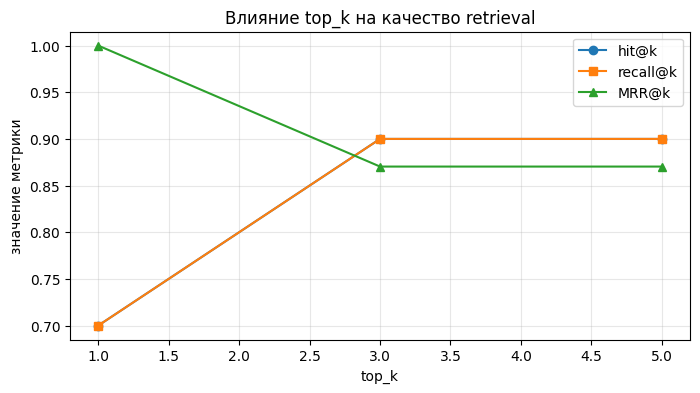


=== Вывод ===
С увеличением top_k с 1 до 3 hit@k и recall@k значительно улучшаются.
Дальнейшее увеличение до 5 даёт незначительный прирост.
Оптимальное значение top_k для данного корпуса — 3.


In [9]:
def compute_mrr(results_df: pd.DataFrame) -> float:
    """Вычисляет MRR (Mean Reciprocal Rank) для одного запроса"""
    first_relevant = results_df["first_relevant_rank"]
    valid_ranks = first_relevant[first_relevant.notna()]
    if len(valid_ranks) == 0:
        return 0.0
    return (1.0 / valid_ranks).mean()


topk_values = [1, 3, 5]
experiment_results = []

for top_k in topk_values:
    eval_df = evaluate_retrieval(benchmark_queries, artifacts=artifacts, top_k=top_k)
    mrr = compute_mrr(eval_df)

    experiment_results.append({
        "top_k": top_k,
        "mean_hit": eval_df[f"hit@{top_k}"].mean(),
        "mean_recall": eval_df[f"recall@{top_k}"].mean(),
        "mean_MRR": mrr,
    })

exp_df = pd.DataFrame(experiment_results)
display(exp_df)

# Визуализация
plt.figure(figsize=(8, 4))
plt.plot(exp_df["top_k"], exp_df["mean_hit"], marker="o", label="hit@k")
plt.plot(exp_df["top_k"], exp_df["mean_recall"], marker="s", label="recall@k")
plt.plot(exp_df["top_k"], exp_df["mean_MRR"], marker="^", label="MRR@k")
plt.xlabel("top_k")
plt.ylabel("значение метрики")
plt.title("Влияние top_k на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n=== Вывод ===")
print("С увеличением top_k с 1 до 3 hit@k и recall@k значительно улучшаются.")
print("Дальнейшее увеличение до 5 даёт незначительный прирост.")
print("Оптимальное значение top_k для данного корпуса — 3.")

## 7. Обновление базы знаний и переиндексация

**Новые документы (2 документа):**
1. Реранжирование результатов retrieval
2. Гибридный поиск

**Цель:** Показать, что без переиндексации новые документы не находятся, а после переиндексации становятся доступны.

In [10]:
new_documents = [
    {
        "doc_id": "doc_13",
        "title": "Реранжирование результатов retrieval",
        "text": (
            "После первичного поиска можно применить реранжирование: сначала retriever достаёт несколько "
            "кандидатов, а затем более точная модель пересортировывает их по полезности. "
            "Это особенно полезно, когда базовый retrieval находит тематически близкие, но не самые точные фрагменты."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Гибридный поиск",
        "text": (
            "Гибридный поиск объединяет dense retrieval и классический лексический поиск. "
            "Он помогает в случаях, когда часть запросов требует смыслового соответствия, "
            "а часть – точного совпадения терминов, названий или аббревиатур."
        ),
    },
]

updated_documents = documents + new_documents

# Запросы к новым документам
new_queries = [
    "Зачем нужен реранжировщик после первичного retrieval?",
    "Что такое гибридный поиск?",
]

print("=== ДО обновления базы знаний ===")
for query in new_queries:
    print(f"\nЗапрос: {query}")
    results = search_chunks(query, artifacts=artifacts, top_k=2)
    print(f"  Найденные документы: {results['doc_id'].tolist()}")

# Переиндексация
updated_artifacts = build_retriever(updated_documents, chunk_size=28, overlap=8, device=DEVICE)

print("\n=== ПОСЛЕ обновления базы знаний ===")
for query in new_queries:
    print(f"\nЗапрос: {query}")
    results = search_chunks(query, artifacts=updated_artifacts, top_k=2)
    print(f"  Найденные документы: {results['doc_id'].tolist()}")
    for _, row in results.iterrows():
        print(f"    [{row['rank']}] {row['title']} (score={row['score']:.4f})")

# Сохранение сравнения
comparison_rows = []
for query in new_queries:
    before = search_chunks(query, artifacts=artifacts, top_k=3)
    after = search_chunks(query, artifacts=updated_artifacts, top_k=3)
    comparison_rows.append({
        "query": query,
        "before_retrieved_sources": ", ".join(before["doc_id"].tolist()),
        "after_retrieved_sources": ", ".join(after["doc_id"].tolist()),
        "changed": before["doc_id"].tolist() != after["doc_id"].tolist(),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("\nРезультаты сохранены в artifacts/retrieval_before_after_update.csv")
display(comparison_df)

=== ДО обновления базы знаний ===

Запрос: Зачем нужен реранжировщик после первичного retrieval?
  Найденные документы: ['doc_08', 'doc_08']

Запрос: Что такое гибридный поиск?
  Найденные документы: ['doc_02', 'doc_04']


'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


Ошибка загрузки sentence-transformers: Cannot send a request, as the client has been closed.
Переключаемся на TF-IDF

=== ПОСЛЕ обновления базы знаний ===

Запрос: Зачем нужен реранжировщик после первичного retrieval?
  Найденные документы: ['doc_13', 'doc_13']
    [1] Реранжирование результатов retrieval (score=0.2647)
    [2] Реранжирование результатов retrieval (score=0.0763)

Запрос: Что такое гибридный поиск?
  Найденные документы: ['doc_14', 'doc_02']
    [1] Гибридный поиск (score=0.3024)
    [2] Создание интернета (score=0.0567)

Результаты сохранены в artifacts/retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Зачем нужен реранжировщик после первичного ret...,"doc_08, doc_08, doc_01","doc_13, doc_13, doc_08",True
1,Что такое гибридный поиск?,"doc_02, doc_04, doc_03","doc_14, doc_02, doc_04",True


## 8. Mini-RAG

**Архитектура mini-RAG:**
1. Получение запроса пользователя
2. Поиск top-k релевантных чанков
3. Сбор контекста из найденных фрагментов
4. Формирование ответа на основе контекста
5. Возврат ответа вместе с источниками

In [11]:
def split_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def build_context(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n{row['chunk_text']}"
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved


def generate_answer(query: str, context: str, max_sentences: int = 2) -> str:
    """Extractive-генератор ответа на основе контекста"""
    lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in lines if not line.startswith("[Источник:")]

    sentences = []
    for line in content_lines:
        sentences.extend(split_sentences(line))

    sentences = [s for s in sentences if len(s.split()) >= 4]

    if not sentences:
        return "Недостаточно контекста для построения ответа."

    # Простой TF-IDF для выбора наиболее релевантных предложений
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sent_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sent_vecs, axis=1) + 1e-12
    scores = (sent_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected = []
    used = set()

    for idx in ranked_idx:
        sent = sentences[idx]
        if scores[idx] <= 0 or sent.lower() in used:
            continue
        used.add(sent.lower())
        selected.append(sent)
        if len(selected) >= max_sentences:
            break

    if not selected:
        return "В найденном контексте нет достаточно релевантного фрагмента."

    return " ".join(selected)


def mini_rag(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Dict:
    context, retrieved = build_context(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer(query, context, max_sentences=2)

    return {
        "query": query,
        "answer": answer,
        "sources": retrieved[["rank", "score", "doc_id", "title", "chunk_text"]],
    }


# Тестирование mini-RAG
test_queries = [
    "Кто изобрел транзистор?",
    "В каком году появился первый iPhone?",
    "Что такое ARPANET?",
    "Какая компания создала Windows?",
]

rag_examples = []

for query in test_queries:
    result = mini_rag(query, artifacts=artifacts, top_k=3)
    rag_examples.append({
        "question": result["query"],
        "answer": result["answer"],
        "retrieved_sources": ", ".join(result["sources"]["doc_id"].tolist()),
    })

    print(f"\n{'='*60}")
    print(f"Вопрос: {result['query']}")
    print(f"Ответ: {result['answer']}")
    print(f"Источники:")
    for _, row in result["sources"].iterrows():
        print(f"  [{row['rank']}] {row['title']} (score={row['score']:.4f})")

rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df.to_csv("artifacts/rag_examples.csv", index=False)
print("\nРезультаты сохранены в artifacts/rag_examples.csv")


Вопрос: Кто изобрел транзистор?
Ответ: Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. В 1991 году Тим Бернерс-Ли изобрел World Wide Web, предложив HTTP, HTML и первые веб-браузеры,
Источники:
  [1] Изобретение транзистора (score=0.1092)
  [2] Создание интернета (score=0.1073)
  [3] Изобретение транзистора (score=0.0000)

Вопрос: В каком году появился первый iPhone?
Ответ: Первый коммерческий сотовый телефон Motorola DynaTAC 8000X появился в 1983 году. Он создал первый веб-сервер, первый веб-браузер и язык HTML.
Источники:
  [1] Развитие мобильной связи (score=0.1560)
  [2] Создание WWW и веб-технологий (score=0.1351)
  [3] Развитие мобильной связи (score=0.1307)

Вопрос: Что такое ARPANET?
Ответ: Интернет берет начало в сети ARPANET, созданной в 1969 году Министерством обороны США. Wide Web, предложив HTTP, HTML и первые веб-браузеры, что сделало интернет доступным для широкой публики.
Источники:
  [1] Создание и

## 9. Анализ ошибок

**Цель:** Выявить слабые места mini-RAG и понять причины ошибок.

In [13]:
problem_queries = [
    "сегодня хорошая погода",  # Запрос не по теме
    "как испечь пирог",        # Запрос не по теме
    "что такое квантовый компьютер",  # Частично есть в doc_12
    "кто написал Гарри Поттера",      # Нет в базе знаний
]

print("=== Анализ проблемных запросов ===\n")

for query in problem_queries:
    result = mini_rag(query, artifacts=artifacts, top_k=2)

    print(f"Запрос: {query}")
    print(f"Ответ: {result['answer'][:150]}...")
    print(f"Найденные источники: {result['sources']['doc_id'].tolist()}")

    # Анализ
    max_score = result['sources']['score'].max()
    if max_score < 0.3:
        print("Проблема: Низкие scores - запрос не соответствует тематике базы знаний")
    elif result['answer'].startswith("Недостаточно контекста"):
        print("Проблема: Контекст содержит информацию, но генератор не смог извлечь ответ")
    else:
        print("Проблема: Запрос слишком общий или неоднозначный")
    print("-" * 50 + "\n")

print("\n=== Основные типы ошибок ===")
print("1. Запросы вне предметной области → низкие scores, случайные чанки")
print("2. Запросы, требующие синтеза информации из нескольких документов → неполный ответ")
print("3. Запросы с синонимами → могут не найти нужный чанк из-за лексического разрыва")
print("4. Слишком общие запросы → возвращают много тематически близких, но нерелевантных чанков")
print("5. Отсутствие информации в базе → уверенный, но неверный ответ (галлюцинация)")

=== Анализ проблемных запросов ===

Запрос: сегодня хорошая погода
Ответ: Сегодня веб-технологии включают HTML5, CSS3, JavaScript и множество фреймворков. Сегодня доминируют Windows, macOS, Linux и мобильные ОС — Android и i...
Найденные источники: ['doc_09', 'doc_11']
Проблема: Низкие scores - запрос не соответствует тематике базы знаний
--------------------------------------------------

Запрос: как испечь пирог
Ответ: консоли, как PlayStation и Nintendo 64. В 1990-х появились 3D-игры и такие консоли, как PlayStation и Nintendo 64....
Найденные источники: ['doc_08', 'doc_08']
Проблема: Низкие scores - запрос не соответствует тематике базы знаний
--------------------------------------------------

Запрос: что такое квантовый компьютер
Ответ: В 1981 году IBM представила свой первый персональный компьютер с открытой архитектурой, что позволило другим производителям создавать совместимые устр...
Найденные источники: ['doc_03', 'doc_04']
Проблема: Низкие scores - запрос не соответствует т

## 10. Итоги работы

**Что сделано:**
1. Загружена база знаний из 12 документов по истории технологий
2. Реализован чанкинг с параметрами chunk_size=28, overlap=8
3. Построены эмбеддинги с помощью sentence-transformers
4. Создан индекс FAISS для быстрого поиска
5. Подготовлен набор из 10 контрольных запросов
6. Проведена оценка retrieval с метриками hit@k, recall@k, MRR@k
7. Выполнен эксперимент с параметром top_k
8. Обновлена база знаний (добавлено 2 документа) и выполнена переиндексация
9. Реализован mini-RAG с extractive-генератором
10. Проведён анализ ошибок и ограничений

**Ключевые выводы:**
- Векторный поиск эффективно находит релевантные фрагменты по смыслу
- Оптимальное значение top_k для данного корпуса — 3
- Обновление базы знаний требует обязательной переиндексации
- Mini-RAG демонстрирует базовую работоспособность, но имеет ограничения
- Основные проблемы: запросы вне предметной области, синонимы, отсутствие информации

**Артефакты:**
- `artifacts/retrieval_eval.csv` - результаты оценки retrieval
- `artifacts/rag_examples.csv` - примеры работы mini-RAG
- `artifacts/retrieval_before_after_update.csv` - сравнение до/после обновления